In [17]:
# Cell 1: Setup and imports
%env XLA_PYTHON_CLIENT_PREALLOCATE=False
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np

DIRS = ["./power2WF/heavyfactor4", "./power2WF/heavyfactor05"]
data = {}  # keyed by dim
for DIR in DIRS:
    data[DIR] = {}
    _data = {}
    for file in os.listdir(DIR):
        if file.endswith(".pkl") and file.startswith("_median"):
            with open(os.path.join(DIR, file), "rb") as f:
                my_pkl = pickle.load(f)
    
            dim = my_pkl['config']['dim']
            true_Z = float(jnp.exp(my_pkl['config']['logZ']))
            result = my_pkl['res'][4]
            if dim in _data.keys():
                _data[dim]['logZoverZ'] = jnp.concatenate([ _data[dim]['logZoverZ'] , result], axis=0)
            else:
                _data[dim] = {
                'logZoverZ': result,
                'true_Z': true_Z
                }
    eps = 0.001
    J = 10
    for dim in _data.keys():
        n, T = _data[dim]["logZoverZ"].shape
        max_n = n//J * J
        logZoverZ = _data[dim]["logZoverZ"][:max_n]
        logZoverZ = logZoverZ.reshape((max_n//J, J, T))
    #    ZoverZ = jnp.exp(logZoverZ)
        Zmed = jnp.prod(jnp.exp(jnp.median(logZoverZ, axis=1)), axis=-1)
        _data[dim]["Zmed"] = Zmed
    data[DIR] = _data.copy()

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


W0324 12:07:38.836550  132484 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200 NVL. Using default config.
W0324 12:07:38.868758  132484 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200 NVL. Using default config.
W0324 12:07:38.897981  132484 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200 NVL. Using default config.
W0324 12:07:38.976362  132484 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200 NVL. Using default config.
W0324 12:07:39.007578  132484 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200 NVL. Using default config.
W0324 12:07:39.036718  132484 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200 NVL. Using default config.
W0324 12:07:39.069186  132484 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200 NVL. Using default config.
W0324 12:07:39.098329  132484 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200 NVL

In [16]:
data

{'./power2WF/heavyfactor05': {50: {'logZoverZ': Array([[-4.9780436, -4.279701 , -4.330988 , ...,  0.       ,  0.       ,
            0.       ],
          [-4.978422 , -4.2870407, -4.3234177, ...,  0.       ,  0.       ,
            0.       ],
          [-4.978652 , -4.285804 , -4.314253 , ...,  0.       ,  0.       ,
            0.       ],
          ...,
          [-4.9784384, -4.306959 , -4.2993793, ...,  0.       ,  0.       ,
            0.       ],
          [-4.979493 , -4.2851477, -4.3085976, ...,  0.       ,  0.       ,
            0.       ],
          [-4.979764 , -4.2689447, -4.412034 , ...,  0.       ,  0.       ,
            0.       ]], dtype=float32),
   'true_Z': 82.19808197021484,
   'Zmed': Array([5.7231607e-13, 5.6438811e-13, 5.6620241e-13, 5.7991345e-13,
          5.8706300e-13, 5.6241844e-13, 5.5883721e-13, 5.8150116e-13,
          5.6966985e-13, 5.5568717e-13, 5.4361171e-13, 5.7583235e-13],      dtype=float32)}}}

In [18]:
data2 = {}
for DIR in DIRS:
    data2[DIR] = {}
    _data2 = {}
    for file in os.listdir(DIR):
        if file.endswith(".pkl") and file.startswith("__"):
            with open(os.path.join(DIR, file), "rb") as f:
                my_pkl = pickle.load(f)
    
            dim = my_pkl['config']['dim']
            true_Z = float(jnp.exp(my_pkl['config']['logZ']))
            result = my_pkl['res'][4]
            if dim in _data2.keys():
                _data2[dim]['logZoverZ'] = jnp.concatenate([_data2[dim]['logZoverZ'] , result], axis=0)
            else:
                _data2[dim] = {
                'logZoverZ': result,
                'true_Z': true_Z
                }
    for dim in _data2.keys():
        _data2[dim]["Z"] = jnp.exp(_data2[dim]['logZoverZ'].sum(axis=-1))
    data2[DIR] = _data2.copy()

W0324 12:07:41.677635  132484 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200 NVL. Using default config.
W0324 12:07:41.706896  132484 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200 NVL. Using default config.
W0324 12:07:41.738789  132484 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200 NVL. Using default config.
W0324 12:07:41.769070  132484 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200 NVL. Using default config.
W0324 12:07:41.799080  132484 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200 NVL. Using default config.
W0324 12:07:41.828877  132484 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200 NVL. Using default config.


In [21]:
data2['./power2WF/heavyfactor05']

{1: {'logZoverZ': Array([[-0.74509335,  0.        ],
         [-0.74109554,  0.        ],
         [-0.7417507 ,  0.        ],
         [-0.73140955,  0.        ],
         [-0.74294186,  0.        ],
         [-0.7443161 ,  0.        ],
         [-0.7562566 ,  0.        ],
         [-0.7604327 ,  0.        ],
         [-0.7185159 ,  0.        ],
         [-0.72661924,  0.        ],
         [-0.723938  ,  0.        ],
         [-0.72799826,  0.        ],
         [-0.6941662 ,  0.        ],
         [-0.7581892 ,  0.        ],
         [-0.7455635 ,  0.        ],
         [-0.72088146,  0.        ],
         [-0.7641177 ,  0.        ],
         [-0.7227578 ,  0.        ],
         [-0.7586627 ,  0.        ],
         [-0.7488017 ,  0.        ]], dtype=float32),
  'true_Z': 0.4773532748222351,
  'Z': Array([0.47469   , 0.4765915 , 0.47627935, 0.4812302 , 0.4757124 ,
         0.47505906, 0.46942037, 0.46746412, 0.48747522, 0.48354095,
         0.4848392 , 0.48287463, 0.49949077, 0.46851

In [26]:
data['./power2WF/heavyfactor4'][50]["Zmed"]

Array([7.1225276e+34, 5.3885336e+34, 5.1321513e+34, 5.0945011e+34,
       6.3126772e+34, 5.2564340e+34, 3.6663746e+34, 4.2706302e+34,
       5.3531236e+34, 7.7852281e+34, 8.0410658e+34, 6.7606852e+34],      dtype=float32)

In [27]:
data2['./power2WF/heavyfactor4'][50]["Z"]

Array([3.4883536e+34, 3.8935888e+34, 3.9371116e+34, 3.0227441e+34,
       4.7534852e+34, 5.0043132e+34, 4.3282301e+34, 4.9902829e+34,
       5.2653234e+34, 5.5507345e+34, 3.1770303e+34, 3.3491418e+34,
       2.9005198e+34, 6.7634394e+34, 5.6263290e+34, 3.9840679e+34,
       5.4121090e+34, 3.0475677e+34, 6.3690005e+34, 4.2808734e+34],      dtype=float32)

In [10]:
dims = list(data.keys())
dims.sort()
dims = dims[:-1
eps_grid = np.linspace(0.000001, 0.05, 60)
for dim in dims:
    tail_mc = [np.mean(np.abs((data2[dim]["Z"]-data2[dim]["true_Z"])/data2[dim]["true_Z"]) > eps) for eps in eps_grid]
    tail_med = [np.mean(np.abs((data[dim]["Zmed"]-data2[dim]["true_Z"])/data2[dim]["true_Z"]) > eps) for eps in eps_grid]
    plt.plot(eps_grid, tail_mc)
    plt.plot(eps_grid, tail_med, label=f"med {dim}")
    plt.legend()
    plt.show()

SyntaxError: '[' was never closed (4047329886.py, line 3)

(12,)
(20,)
(12,)
(20,)


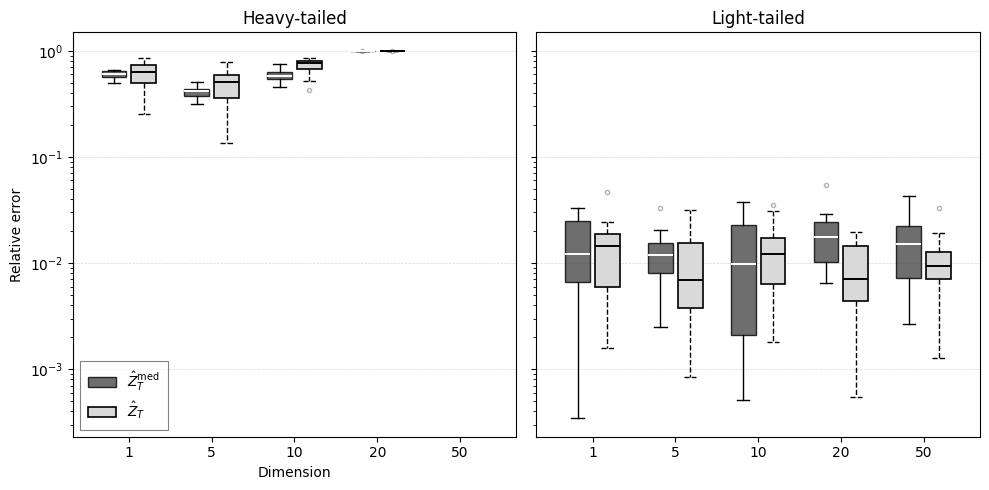

In [23]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, len(DIRS), figsize=(5 * len(DIRS), 5), sharey=True)

if len(DIRS) == 1:
    axes = [axes]

titles = {"./power2WF/heavyfactor4": "Heavy-tailed", "./power2WF/heavyfactor05":"Light-tailed"}


for ax_idx, (DIR, ax) in enumerate(zip(DIRS, axes)):
    dims = list(data[DIR].keys())
    dims.sort()
    dims = list(filter(lambda dim: dim != 100, dims))
    print(data[DIR][dim]["Zmed"][:200].shape)
    print(data2[DIR][dim]["Z"][:200].shape)
    box1 = [np.abs((data[DIR][dim]["Zmed"][:200] - data[DIR][dim]["true_Z"]) / data[DIR][dim]["true_Z"]) for dim in dims]
    box2 = [np.abs((data2[DIR][dim]["Z"][:200]    - data[DIR][dim]["true_Z"]) / data[DIR][dim]["true_Z"]) for dim in dims]

    positions1 = [i - 0.18 for i in range(len(dims))]
    positions2 = [i + 0.18 for i in range(len(dims))]

    common_props = dict(linewidth=1)

    b1 = ax.boxplot(
        box1,
        positions=positions1,
        widths=0.3,
        patch_artist=True,
        boxprops=dict(facecolor="#4a4a4a", edgecolor="black", alpha=0.8, **common_props),
        medianprops=dict(color="white", linewidth=1.4),
        whiskerprops=dict(color="black", **common_props),
        capprops=dict(color="black", **common_props),
        flierprops=dict(marker='o', markersize=3, alpha=0.3)
    )

    b2 = ax.boxplot(
        box2,
        positions=positions2,
        widths=0.3,
        patch_artist=True,
        boxprops=dict(facecolor="#d9d9d9", edgecolor="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(color="black", linestyle="--", **common_props),
        capprops=dict(color="black", linestyle="--", **common_props),
        flierprops=dict(marker='o', markersize=3, alpha=0.3)
    )

    ax.set_xticks(range(len(dims)))
    ax.set_xticklabels(dims)
    ax.set_yscale("log")
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_title(titles[DIR])

    # Only label y-axis and add legend on the first subplot
    if ax_idx == 0:
        ax.set_xlabel("Dimension")
        ax.set_ylabel("Relative error")
        leg = ax.legend(
            [b1["boxes"][0], b2["boxes"][0]],
            [r"$\hat{Z}_T^{\mathrm{med}}$", r"$\hat{Z}_T$"],
            loc="lower left",
            frameon=True,
            facecolor="white",
            edgecolor="0.3",
            framealpha=0.7,
            fancybox=False,
            borderpad=0.6
        )
        leg.set_zorder(10)
        leg.get_frame().set_linewidth(0.8)

plt.tight_layout()
plt.savefig(DIRS[0] + "plots.pdf", dpi=300)
plt.show()

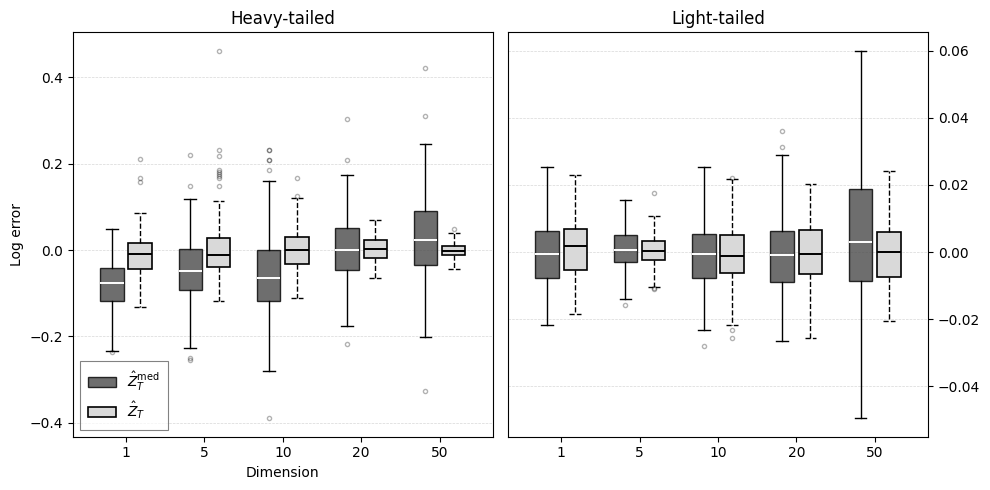

In [23]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, len(DIRS), figsize=(5 * len(DIRS), 5))

if len(DIRS) == 1:
    axes = [axes]


for ax_idx, (DIR, ax) in enumerate(zip(DIRS, axes)):
    dims = list(data[DIR].keys())
    dims.sort()
    dims = list(filter(lambda dim: dim != 100, dims))

    box1 = [np.log(data[DIR][dim]["Zmed"][:200] / data[DIR][dim]["true_Z"]) for dim in dims]
    box2 = [np.log(data2[DIR][dim]["Z"][:200]   / data[DIR][dim]["true_Z"]) for dim in dims]

    positions1 = [i - 0.18 for i in range(len(dims))]
    positions2 = [i + 0.18 for i in range(len(dims))]

    common_props = dict(linewidth=1)

    b1 = ax.boxplot(
        box1,
        positions=positions1,
        widths=0.3,
        patch_artist=True,
        boxprops=dict(facecolor="#4a4a4a", edgecolor="black", alpha=0.8, **common_props),
        medianprops=dict(color="white", linewidth=1.4),
        whiskerprops=dict(color="black", **common_props),
        capprops=dict(color="black", **common_props),
        flierprops=dict(marker='o', markersize=3, alpha=0.3)
    )

    b2 = ax.boxplot(
        box2,
        positions=positions2,
        widths=0.3,
        patch_artist=True,
        boxprops=dict(facecolor="#d9d9d9", edgecolor="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(color="black", linestyle="--", **common_props),
        capprops=dict(color="black", linestyle="--", **common_props),
        flierprops=dict(marker='o', markersize=3, alpha=0.3)
    )

    ax.set_xticks(range(len(dims)))
    ax.set_xticklabels(dims)
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_title(titles[DIR])

    if ax_idx == 0:
        ax.set_xlabel("Dimension")
        ax.set_ylabel("Log error")

        leg = ax.legend(
            [b1["boxes"][0], b2["boxes"][0]],
            [r"$\hat{Z}_T^{\mathrm{med}}$", r"$\hat{Z}_T$"],
            loc="lower left",
            frameon=True,
            facecolor="white",
            edgecolor="0.3",
            framealpha=0.7,
            fancybox=False,
            borderpad=0.6
        )
        leg.set_zorder(10)
        leg.get_frame().set_linewidth(0.8)

    else:
        # Put y-axis on the right for second plot
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

plt.tight_layout()
plt.savefig(DIRS[0] + "log_errors_plots.pdf", dpi=300)
plt.show()